#Positional Encoding — Adding Order to Parallelism

Yesterday, we learned that Multi-Head Attention processes all words in a sentence simultaneously. While this is fast, it creates a problem: the model has no idea which word comes first. To a Transformer, "The cat ate the fish" and "The fish ate the cat" look identical because there is no sequence.

Positional Encoding fixes this by adding a unique mathematical signature to each word embedding that describes its position in the sentence.

1. **#The Sine and Cosine Formula**
Instead of just adding 1, 2, 3 (which can get too large for long sentences), we use a combination of Sine and Cosine functions at different frequencies. This ensures that the model can learn the relative distance between words easily.

The formula for a position $pos$ and dimension $i$ is:

$$PE(pos, 2i) = \sin(pos / 10000^{2i/d_{model}})$$
$$PE(pos, 2i+1) = \cos(pos / 10000^{2i/d_{model}})$$

2. **Implementation in Python**

Here is how you can generate these encodings using NumPy to visualize the pattern.

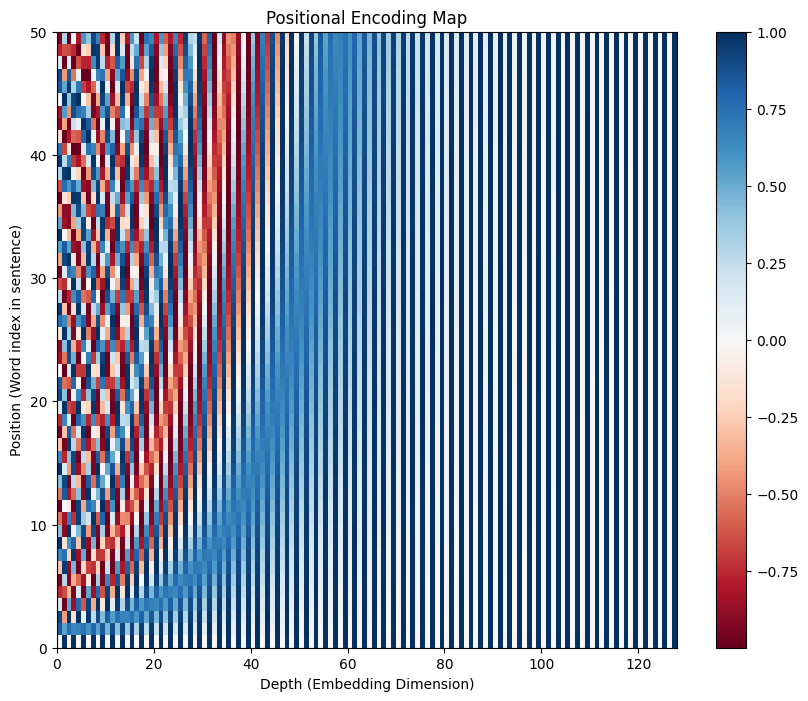

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_positional_encoding(max_seq_len, d_model):
    # Initialize matrix
    pos_enc = np.zeros((max_seq_len, d_model))
    
    for pos in range(max_seq_len):
        for i in range(0, d_model, 2):
            # Calculate the denominator part
            div_term = np.exp(i * -np.log(10000.0) / d_model)
            
            # Apply sine to even indices
            pos_enc[pos, i] = np.sin(pos * div_term)
            # Apply cosine to odd indices
            pos_enc[pos, i + 1] = np.cos(pos * div_term)
            
    return pos_enc

# Visualize the encoding
pe = get_positional_encoding(max_seq_len=50, d_model=128)
plt.figure(figsize=(10, 8))
plt.pcolormesh(pe, cmap='RdBu')
plt.xlabel('Depth (Embedding Dimension)')
plt.ylabel('Position (Word index in sentence)')
plt.colorbar()
plt.title("Positional Encoding Map")
plt.show()

3. **Why This Works**
- **Consistency:** The encoding for position 3 is always the same, no matter the sentence length.
- **Relative Distance:** Because of the sine/cosine relationship, the model can easily compute that word $A$ is 2 steps away from word $B$.
- **Vector Addition:** We add these values directly to our word embeddings ($Embedding + Positional\_Encoding$).